### This notebook compute "P10. Volume of the glacial lagoon" indicator for the 27 basins of IKI Project

Spanish: Volumen de la laguna glaciar

**Created:** 6/23/2025 by Jorge Mayo (jmayo@rti.org) / Serena Gilson 

**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020 https://geocatmin.ingemmet.gob.pe/geocatmin/
 
**Assumptions:** Used COMID to associate lagoons that are "below" a glacier. 

Could not find lagoon depth so assumed average depth of .03 for all. Used km for ranges and seemed to have an appropriate distribution. 
 
**N/A Handling:** COMIDs without lagoons are NaN in level assignments.

**Notes:**  

General methodology:  
1. Spatial join COMIDs and lagoon datasets.  
2. Calculate the area of each lagoon (km2). Convert to volume using an assumed depth of 0.03 km. 
3. Calculate total lagoon volume per COMID.  
4. Filter for COMIDs with glaciers to determine which lagoons are glacial lagoons.  
5. Assign a lagoon volume score: NaN for 0 km,  1 for volumes > 50 km3, 0.75 for volumes (20, 50] km3; 0.50 for volumes (10, 20] km3; 0.25 for volums < 10 km3.  

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio
import yaml
from pathlib import Path

In [ ]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [ ]:
# set paths for input data and indicators database 
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
glaciares_actual = master_path / "Indicadores" / "Datos_INAIGEM" / "Glaciares_2020_COMID_v2.shp"
mapa_ecosistemas = master_path / "Indicadores" / "Datos_MINAM" / "MAPA_NACIONAL_DE_ECOSISTEMAS_20-12-2018.shp"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 110 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()


In [5]:
#read ecosystems shapefile
mapa_ecosistemas_gdf= gpd.read_file(mapa_ecosistemas)

#Filter mapa_ecosistemas_gdf for ECO_LAYER= "Lagos and Lagunas"
mapa_lag_gdf = mapa_ecosistemas_gdf[mapa_ecosistemas_gdf['ECO_LAYER'] == 'Lago y laguna']

# read in the subbasins and glaciers shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_actual_gdf = gpd.read_file(glaciares_actual).to_crs('EPSG:32718')

In [6]:
# For each COMID that has a glacier, calculate the volume of water in km³ in the lagoons in that COMID

# Step 1: Spatial join to get lagoons within each subbasin COMID
mapa_lag_gdf = mapa_lag_gdf.to_crs(subbasins_gdf.crs)  # Ensure same CRS
subbasins_with_lagoon = gpd.sjoin(subbasins_gdf, mapa_lag_gdf, how='inner', predicate='intersects')

# Step 2: Calculate the area of each lagoon in km²
subbasins_with_lagoon['Lagoon_Area_Km2'] = subbasins_with_lagoon.geometry.area / 1_000_000  # Convert m² to km²

# Step 3: Estimate volume using a simplified formula
# Assuming average depth (you may need to adjust this based on your data)
# Common assumption: Volume (km³) = Area (km²) × Average Depth (km)
# For glacial lagoons, typical depths range from 10-50 meters (0.01-0.05 km)
average_depth_km = 0.03  # 30 meters average depth (adjust as needed)

subbasins_with_lagoon['Lagoon_Volume_Km3'] = subbasins_with_lagoon['Lagoon_Area_Km2'] * average_depth_km

# Step 4: Group by COMID and sum the total volume
lagoon_volume_by_comid = subbasins_with_lagoon.groupby('COMID')['Lagoon_Volume_Km3'].sum().reset_index()

# Step 5: Filter for COMIDs that have glaciers
comids_with_glaciers = glaciares_actual_gdf['COMID'].unique()
lagoon_volume_with_glaciers = lagoon_volume_by_comid[lagoon_volume_by_comid['COMID'].isin(comids_with_glaciers)]

# Step 6: Merge with subbasins_gdf to get geometry for mapping
subbasins_with_volume = subbasins_gdf.merge(lagoon_volume_with_glaciers, on='COMID', how='left')

# Fill NaN values with 0 for COMIDs without lagoons
subbasins_with_volume['Lagoon_Volume_Km3'] = subbasins_with_volume['Lagoon_Volume_Km3'].fillna(0)

# Round to appropriate decimal places
subbasins_with_volume['Lagoon_Volume_Km3'] = subbasins_with_volume['Lagoon_Volume_Km3'].round(4)

# Display results
print(f"Total COMIDs with glaciers and lagoons: {len(lagoon_volume_with_glaciers)}")
print(f"\nTop 10 COMIDs by lagoon volume:")
print(lagoon_volume_with_glaciers.nlargest(10, 'Lagoon_Volume_Km3'))


Total COMIDs with glaciers and lagoons: 181

Top 10 COMIDs by lagoon volume:
         COMID  Lagoon_Volume_Km3
286  309326900         443.063674
242  309080700         186.493609
76   307542200         156.798929
232  308988000         127.323208
293  309352700          99.451046
346  309724200          96.014255
274  309249800          83.209127
179  308526600          81.065588
73   307445100          71.568272
244  309097100          69.435637


In [8]:
# Assign the following values based on lagoon volume: 
# Volumen de la laguna (m³): Valor
# Mayor a 50 Mm³: 1
# 20 Mm³ a 50 Mm³: 0.75
# 10 Mm³ a 20 Mm³: 0.50
# Menos 10 Mm³: 0.25
# Sin laguna: N/A

#Upon looking at distributions, km3 seems to be more appropriate for the scoring numbers

# Convert volume from km³ to Mm³ (million cubic meters)
# 1 km³ = 1,000 Mm³
#subbasins_with_volume['Lagoon_Volume_Mm3'] = subbasins_with_volume['Lagoon_Volume_Km3'] * 1000

# Function to assign scores based on volume
def assign_lagoon_score(volume_km3):
    if volume_km3 == 0 or pd.isna(volume_km3):
        return np.nan  # Sin laguna: N/A
    elif volume_km3 > 50:
        return 1  # Mayor a 50 Mm³
    elif 20 <= volume_km3 <= 50:
        return 0.75  # 20 Mm³ a 50 Mm³
    elif 10 <= volume_km3 < 20:
        return 0.50  # 10 Mm³ a 20 Mm³
    else:  # volume_km3 < 10
        return 0.25  # Menos 10 Mm³

# Apply the scoring function
subbasins_with_volume['Lagoon_Volume_Score'] = subbasins_with_volume['Lagoon_Volume_Km3'].apply(assign_lagoon_score)
# Display summary statistics
print("Score Distribution:")
print(subbasins_with_volume['Lagoon_Volume_Score'].value_counts().sort_index())
print(f"\nCOMIDs with no lagoons (N/A): {subbasins_with_volume['Lagoon_Volume_Score'].isna().sum()}")



Score Distribution:
Lagoon_Volume_Score
0.25    99
0.50    33
0.75    33
1.00    16
Name: count, dtype: int64

COMIDs with no lagoons (N/A): 3474


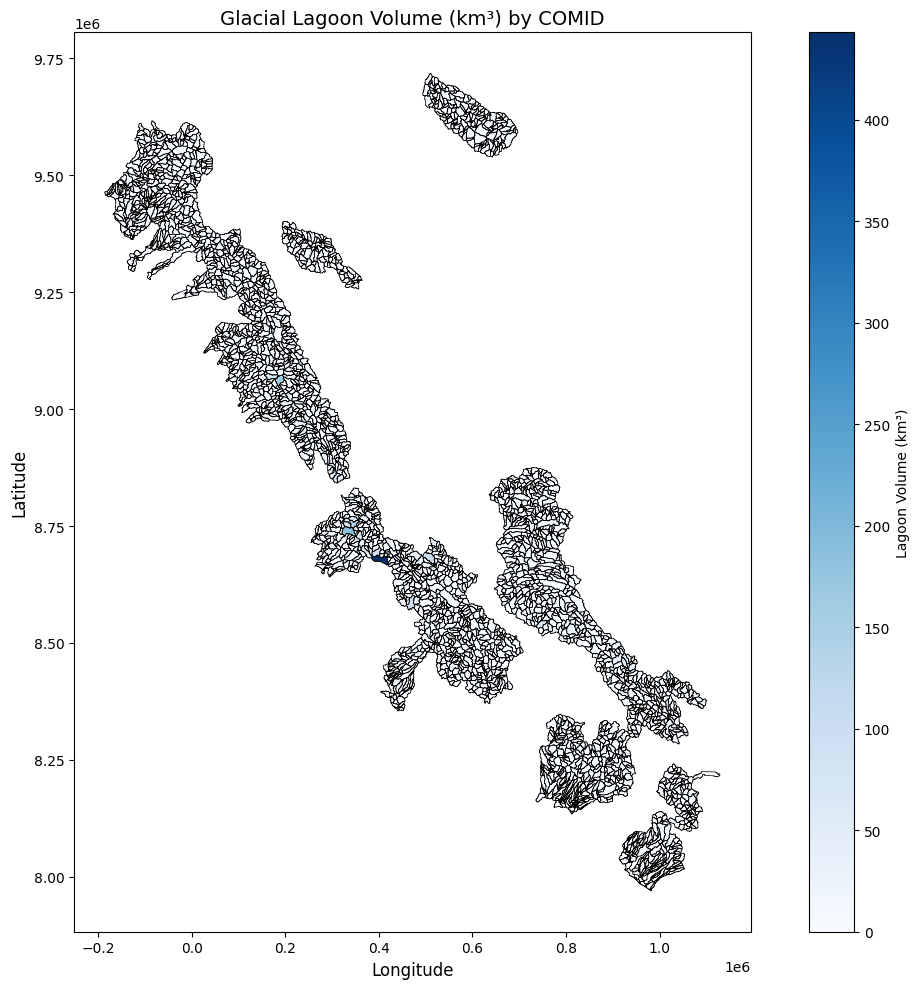

In [9]:
# Plot lagoon volume in map format
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
subbasins_with_volume.plot(column='Lagoon_Volume_Km3', ax=ax, legend=True, 
                            cmap='Blues', edgecolor='black', linewidth=0.5,
                            legend_kwds={'label': 'Lagoon Volume (km³)'})
ax.set_title('Glacial Lagoon Volume (km³) by COMID', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
insert_data= subbasins_with_volume #COMID 
value_column= 'Lagoon_Volume_Score' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [11]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_with_volume['Lagoon_Volume_Score']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 110  Min: 1, Max: 4

=== Values to be inserted (by scenario) ===
   index  Lagoon_Volume_Score
0    min                 0.25
1    max                 1.00
2  count               181.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()